# Extended Model 3: Day 7–28 Evaluation

## tl;dr

The extension is technically feasible, but the evidence does **not** support replacing Trish's final Model 3 with a larger all-feature CatBoost.

- Trish's separately trained terminal Day-21 model reports **103.7 g MAE** under leave-one-building-flock-out validation across all 34 flocks.
- Under the stricter leave-one-production-cycle-out design on 31 development flocks, the reduced extended CatBoost reaches **114.4 g cycle-macro MAE** across Days 7, 14, 21, and 28.
- Its checkpoint MAE is **129.1 g at Day 7**, **124.0 g at Day 14**, **125.1 g at Day 21**, and **123.8 g at Day 28**.
- A transparent historical remaining-gain method is slightly weaker in development but materially stronger on the three-building 2026-3 audit. It is the safer provisional checkpoint outlook.

**Recommendation:** retain Trish's Model 3 as the established Day-21 benchmark. If Canary needs Days 7, 14, 21, and 28 now, place the historical remaining-gain checkpoint method in shadow use and keep the learned extension experimental until more complete cycles show that it generalizes.


## Context & Methods

### Decision

Can Trish's Day-21 bodyweight model be extended to Days 7, 14, 21, and 28 without sacrificing defensibility?

### Key assumptions

- Day-35 bodyweight is the recorded Day-35 measurement.
- Official checkpoint weights at Days 7, 14, 21, and 28 are observed measurements.
- Forecast rows contain only information available through the checkpoint.
- All buildings from the same production cycle are held out together during development validation.
- The three buildings in cycle 2026-3 are excluded from fitting and used as a later-cycle audit.
- The 2026-3 audit is small and is not a substitute for several future unseen cycles. Upstream Trish feature work used all 34 flocks, so it should be described as a later-cycle audit rather than a perfectly untouched external validation set.

The experiment compares a historical remaining-gain baseline; linear, regularized, robust, tree, boosting, CatBoost, and XGBoost candidates; a full 94-feature CatBoost extension; and a reduced CatBoost using growth features plus Trish's confirmed contextual fields. Fold-local medians are used for missing values. No application files are changed.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if not (ROOT / "scripts" / "extended_model3_experiment.py").exists():
    raise RuntimeError("Run this notebook from Project_Canary_GitHub_Ready or its notebooks directory.")
sys.path.insert(0, str(ROOT / "scripts"))

from extended_model3_experiment import run, OUTPUT_DIR

results = run()
results["data_quality"]

{'rows': 136,
 'flocks': 34,
 'development_flocks': 31,
 'audit_flocks': 3,
 'checkpoints': [7, 14, 21, 28],
 'duplicate_flock_checkpoint_rows': 0,
 'missing_day35_targets': 0,
 'development_cycles': ['2025-2',
  '2025-3',
  '2025-4',
  '2025-5',
  '2026-1',
  '2026-2'],
 'audit_cycle': '2026-3',
 'n_features': 94,
 'actual_checkpoint_weight_source': 'bodyweight_kgs at Days 7, 14, 21, and 28'}

## Data

Each modeling row represents one building-flock at one official weighing checkpoint. The 31 development building-flocks cover cycles 2025-2 through 2026-2. Cycle 2026-3 contributes three later-cycle audit buildings. Repeated checkpoint rows from the same cycle are never split between training and validation.

The feature construction retains Trish's temperature, humidity, THI, feed, mortality, housing, and growth-history definitions. The extension adds the latest observed checkpoint weight, prior checkpoint weight, seven-day gain, gain rate, a simple trajectory projection, checkpoint age, and days remaining to Day 35.


In [2]:
modeling_frame = pd.read_csv(OUTPUT_DIR / "checkpoint_modeling_frame.csv")
pd.DataFrame({
    "check": ["Rows", "Building-flocks", "Development flocks", "Audit flocks", "Duplicate keys", "Missing targets"],
    "result": [
        len(modeling_frame),
        modeling_frame[["harvest_cycle", "bldg"]].drop_duplicates().shape[0],
        modeling_frame.loc[modeling_frame.harvest_cycle != "2026-3", ["harvest_cycle", "bldg"]].drop_duplicates().shape[0],
        modeling_frame.loc[modeling_frame.harvest_cycle == "2026-3", ["harvest_cycle", "bldg"]].drop_duplicates().shape[0],
        modeling_frame.duplicated(["harvest_cycle", "bldg", "prediction_day"]).sum(),
        modeling_frame.bodyweight_at_day_35.isna().sum(),
    ],
})

,check,result
0,Rows,136
1,Building-flocks,34
2,Development flocks,31
3,Audit flocks,3
4,Duplicate keys,0
5,Missing targets,0


## Results

### 1. Candidate comparison

In [3]:
comparison = pd.read_csv(OUTPUT_DIR / "candidate_comparison.csv")
comparison.round({
    "pooled_mae_g": 1,
    "cycle_macro_mae_g": 1,
    "rmse_g": 1,
    "r2": 3,
    "bias_g": 1,
    "worst_cycle_mae_g": 1,
    "within_100g_pct": 1,
    "within_200g_pct": 1,
})

,model,pooled_mae_g,cycle_macro_mae_g,rmse_g,r2,bias_g,worst_cycle_mae_g,within_100g_pct,within_200g_pct
0,catboost_reduced_growth_context,125.5,114.4,162.2,0.324,0.0,196.1,54.0,81.5
1,historical_remaining_gain,127.1,120.9,163.9,0.310,-0.6,183.2,50.8,75.8
2,catboost_extended,143.5,131.2,182.1,0.148,4.6,228.9,47.6,66.1
3,xgboost,156.9,143.2,196.1,0.012,25.0,257.8,45.2,68.5
4,gradient_boosting,163.3,152.6,205.6,-0.086,48.4,265.9,43.5,67.7
5,extra_trees,173.3,158.3,212.8,-0.163,27.6,308.5,42.7,60.5
6,huber,188.3,172.7,238.3,-0.459,54.2,286.9,35.5,54.8
7,ridge,194.4,179.2,246.7,-0.562,45.8,288.8,35.5,58.9
8,linear_regression,549.5,493.1,1029.8,-26.231,201.5,1287.6,28.2,39.5


The full-feature CatBoost extension is weaker than the simpler checkpoint baseline. Reducing the learned model to observed growth plus a small amount of validated context improves development performance, which is consistent with the small effective sample: 31 independent outcomes cannot reliably support a very wide feature set.

### 2. Apples-to-apples Day-21 comparison

The published and strict results answer different questions and must not be placed in one table without their validation labels.


In [4]:
official = results["original_model3_official"]
strict = results["original_model3_strict_day21_reconstruction"]
extended_day21 = results["selected_day21_metrics"]
pd.DataFrame([
    {
        "method": "Trish terminal Day-21 Model 3",
        "validation": "Leave one building-flock out, 34 flocks",
        "scope": "Day 21 only",
        "MAE_g": official["terminal_day21_model_mae_g"],
    },
    {
        "method": "Trish Model 3 strict reconstruction",
        "validation": "Leave one production cycle out, 31 flocks",
        "scope": "Day 21 only",
        "MAE_g": strict["cycle_macro_mae_g"],
    },
    {
        "method": "Reduced extended CatBoost",
        "validation": "Leave one production cycle out, 31 flocks",
        "scope": "Day-21 slice",
        "MAE_g": extended_day21["cycle_macro_mae_g"],
    },
]).round(1)

,method,validation,scope,MAE_g
0,Trish terminal Day-21 Model 3,"Leave one building-flock out, 34 flocks",Day 21 only,103.7
1,Trish Model 3 strict reconstruction,"Leave one production cycle out, 31 flocks",Day 21 only,120.4
2,Reduced extended CatBoost,"Leave one production cycle out, 31 flocks",Day-21 slice,114.6


### 3. Accuracy by checkpoint

In [5]:
checkpoint_metrics = pd.read_csv(OUTPUT_DIR / "selected_checkpoint_metrics.csv")
checkpoint_metrics.round({
    "pooled_mae_g": 1,
    "cycle_macro_mae_g": 1,
    "rmse_g": 1,
    "r2": 3,
    "bias_g": 1,
    "worst_cycle_mae_g": 1,
    "within_100g_pct": 1,
    "within_200g_pct": 1,
})

,prediction_day,pooled_mae_g,cycle_macro_mae_g,rmse_g,r2,bias_g,worst_cycle_mae_g,within_100g_pct,within_200g_pct
0,7,129.1,117.7,163.0,0.318,1.2,186.0,51.6,80.6
1,14,124.0,113.3,160.1,0.342,-6.3,194.9,54.8,83.9
2,21,125.1,114.6,162.5,0.322,-0.6,201.2,54.8,80.6
3,28,123.8,112.1,163.3,0.316,5.8,202.1,54.8,80.6


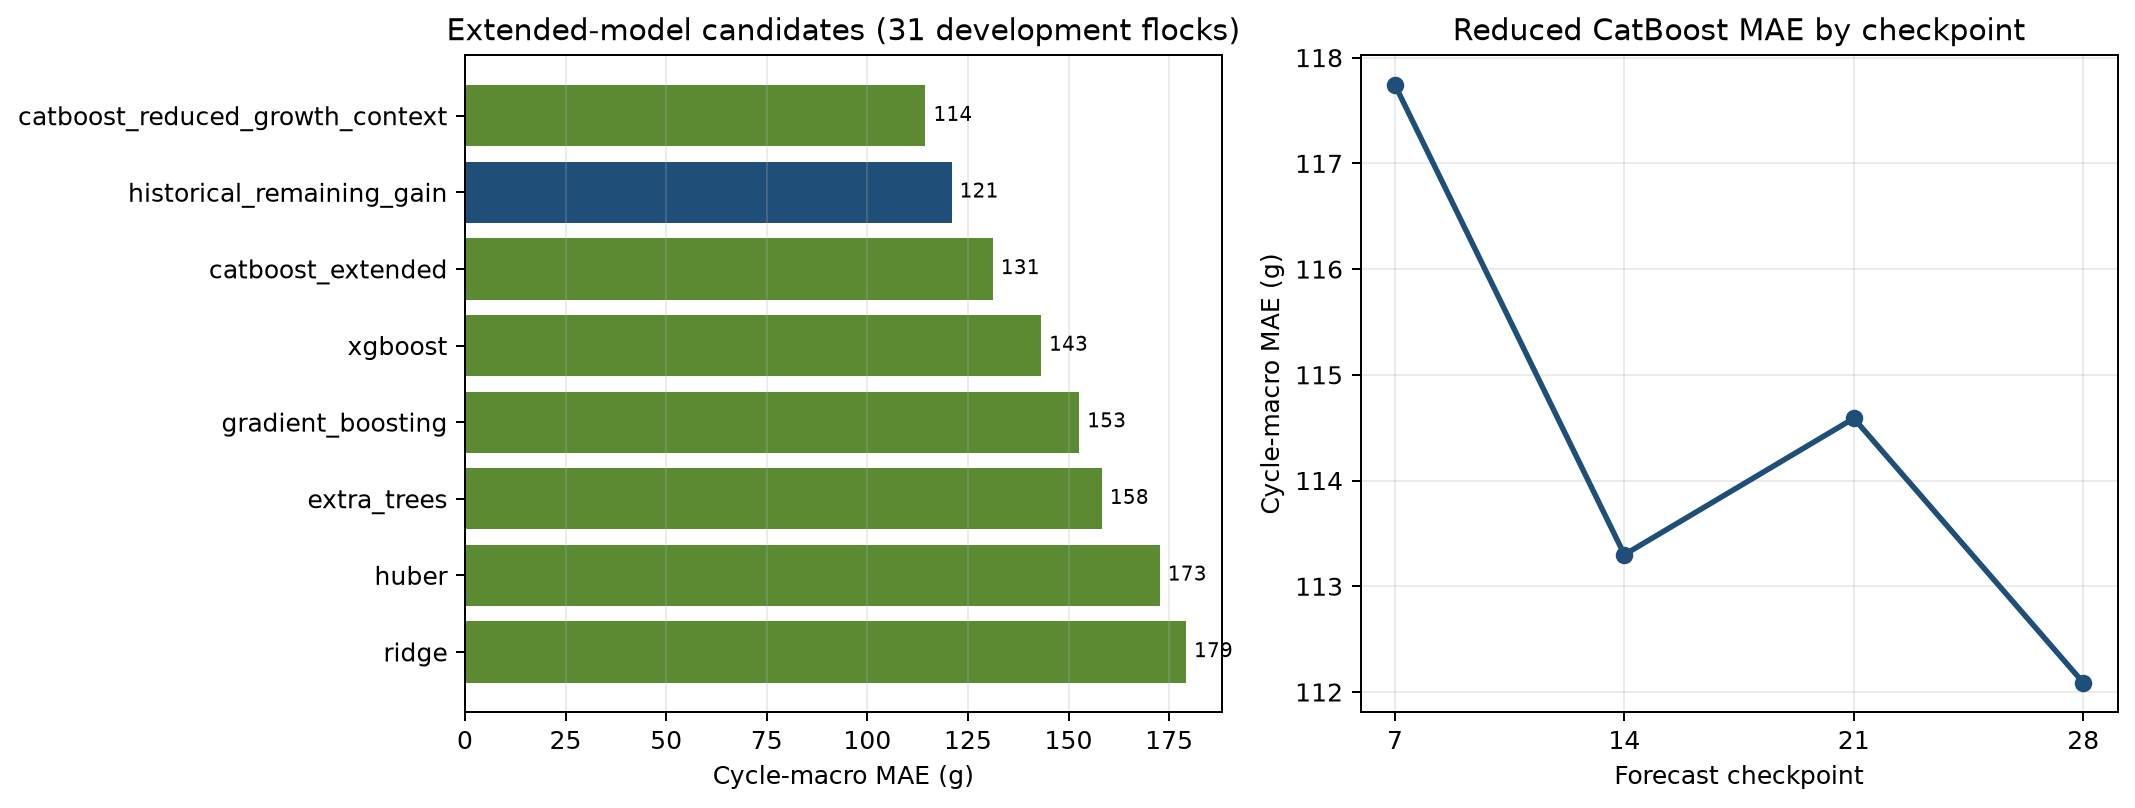

In [6]:
display(Image(filename=str(OUTPUT_DIR / "extended_model3_performance.png")))

### 4. Later-cycle audit

The audit contains only three Tags buildings from one cycle. It is useful as a stability warning, not as a definitive ranking. R² is not interpretable here because the three outcomes occupy a very narrow range; MAE and bias are more informative.


In [7]:
audit_summary = pd.read_csv(OUTPUT_DIR / "audit_2026_3_summary.csv")
audit_summary.round({
    "pooled_mae_g": 1,
    "cycle_macro_mae_g": 1,
    "rmse_g": 1,
    "r2": 3,
    "bias_g": 1,
    "worst_cycle_mae_g": 1,
    "within_100g_pct": 1,
    "within_200g_pct": 1,
})

,model,pooled_mae_g,cycle_macro_mae_g,rmse_g,r2,bias_g,worst_cycle_mae_g,within_100g_pct,within_200g_pct
0,historical_remaining_gain,77.6,77.6,109.7,-8.844,-28.2,77.6,75.0,91.7
1,catboost_extended,105.4,105.4,129.0,-12.607,-105.4,105.4,58.3,75.0
2,catboost_reduced_growth_context,121.4,121.4,136.8,-14.294,-73.4,121.4,33.3,83.3
3,trish_model3_day21_strict_reconstruction,51.0,51.0,51.9,-1.202,12.8,51.0,100.0,100.0


## Takeaways

1. **The extension is possible.** Canary can issue evidence-based Day-35 bodyweight outlooks after the actual Day 7, 14, 21, and 28 weigh-ins.
2. **It is a weekly checkpoint model, not a validated daily bodyweight model.** Between weigh-ins, the forecast should stay unchanged and display the age of its latest weight evidence.
3. **More features did not mean better forecasts.** The full 94-feature CatBoost underperformed the transparent remaining-gain benchmark. The reduced CatBoost improved development MAE but did not generalize as well to 2026-3.
4. **Do not claim that the extension beats Trish's Model 3 based on the published numbers alone.** Trish's 103.66 g result uses leave-one-building-flock-out validation across all 34 flocks; the extension's principal comparison holds out complete production cycles and excludes 2026-3 from fitting.
5. **Recommended decision:** keep Trish's Model 3 as the Day-21 benchmark. Put the historical remaining-gain checkpoint method in shadow mode for Days 7, 14, 21, and 28. Retain the reduced CatBoost as an experimental challenger and reconsider promotion after several new completed cycles.

The forecasts remain planning outlooks. THI, temperature, humidity, mortality, feed, and housing fields are contextual predictors, not proof that changing one factor will cause a specific bodyweight change.
